In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

In [2]:
load_dotenv()

True

In [3]:
# llm=HuggingFaceEndpoint(
#     repo_id="deepseek-ai/DeepSeek-V3.2-Exp",
#     task="text-generation"
# )
# model=ChatHuggingFace(llm=llm)

In [4]:
# model1=ChatGoogleGenerativeAI(model="gemini-1.0-pro")

In [ ]:
model="llama-3.3-70b-versatile",model2=ChatGroq(   # choose any supported Groq model
    temperature=0.7)

In [6]:
class SentimentSchema(BaseModel):
    sentiment:Literal["positive","negative"]=Field(description="Sentiment of the review")
    

In [7]:
class DiagnosisSchema(BaseModel):
    issue_type:Literal["UX","Performance","Bug","Support","Other"]=Field(description="The category of issue mentioned in the review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [8]:
structured_model=model2.with_structured_output(SentimentSchema)
structured_diagnosis_model=model2.with_structured_output(DiagnosisSchema)

In [9]:
! pip install langchain-groq


You should consider upgrading via the 'C:\Users\sudha\Desktop\My_workspace\langgraph\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [10]:
prompt="What is the sentiment of the follwoing review- The software is too bad"
structured_model.invoke(prompt).sentiment

'negative'

In [11]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis:dict
    respnse:str

In [12]:
def find_sentiment(state:ReviewState):

    prompt=f"What is the sentiment of the follwoing review-{state['review']}"
    sentiment=structured_model.invoke(prompt).sentiment
    return {"sentiment":sentiment}

def check_sentiment(state:ReviewState)->Literal["positive_response","run_diagnosis"]:

    if state['sentiment']=='positive':
        return 'positive_respnse'
    else:
        return "run_diagnosis"
    
def positive_response(state: ReviewState):
    prompt=f""" write a warm message in response to this review
    \n\n\"{state['review']}\"\n
    also,kindly ask the user to leave feedback on our website"""

    response=model2.invoke(prompt).content
    return {'response':response}

def run_diagnosis(state:ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""
    response = structured_diagnosis_model.invoke(prompt)

    return {"diagnosis":response.model_dump()}

def negative_response(state: ReviewState):
    diagnosis=state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response=model2.invoke(prompt).content
    return {"respnse":response}

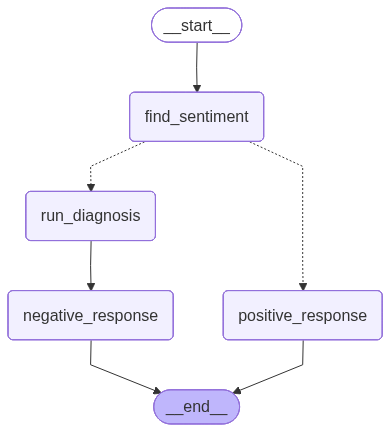

In [14]:
graph=StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)


graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)
graph.add_edge("positive_response",END)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)

workflow=graph.compile()
workflow

In [15]:
initial_state={
     'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(initial_state)


{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'respnse': "I'm so sorry to hear that you're experiencing a frustrating bug issue. I can imagine how angering it must be to encounter an obstacle that's hindering your progress. Please know that I'm here to help and I'm committed to resolving this issue as quickly as possible.\n\nI've escalated your concern to our top priority due to the high urgency you've indicated. I want to assure you that we're taking immediate action to investigate and fix the bug. Our technical team is working diligently to identify the root cause and implement a solution.\n\nIn the meantime, I'd like to offer some troubleshooting steps that may help alleviate the issue. If